# Week 4 Practice Tutorial Solutions: Discover He Initialisation with Autodiff and SGD

**MATH3881 / MATH5881, UNSW.** Instructor: Sarat Moka.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/saratmoka/MATH3881-5881/blob/main/tutorials/week04/Week4_Practice_Tutorial_Solutions.ipynb)

One short experiment that connects **autodiff** (Week 3) and **SGD** (Week 4) to the Week 4 theory tutorial.

We will build a deep ReLU MLP with all weights drawn iid from $\mathcal{N}(0, s_W^2)$. With autograd we will measure the per-layer backprop gradient $\|\delta^{[\ell]}\|$ at random initialisation. With SGD we will train the same network. Then **you** will find the one value of $s_W^2$ at which the gradient is stable across layers *and* SGD trains rapidly.

## Setup

Imports and a fixed seed for reproducibility. The "data" is just a random input batch and random regression target: we are not solving a task, we are studying how the backprop signal propagates through the layers.

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(0)

X = torch.randn(64, 10)   # input batch  (64 samples, 10 features)
y = torch.randn(64, 1)    # random target

## A deep ReLU MLP with controllable initial variance

We build an $L$-hidden-layer width-$n$ ReLU network with no biases (so the setup matches the Week 4 theory tutorial exactly). Every weight entry is drawn iid from $\mathcal{N}(0, s_W^2)$.

Each pre-activation $z^{[\ell]}$ is given `retain_grad()` in the forward pass, which tells autograd to keep `z.grad` around after `loss.backward()`. That gradient is exactly $\delta^{[\ell]} := \partial C/\partial z^{[\ell]}$, the quantity the theory tutorial called $\delta^{[\ell]}$.

Two helpers are defined: `probe(s_squared)` runs one forward + backward and returns the list of $\|\delta^{[\ell]}\|$ per layer; `train(s_squared)` runs $K$ steps of vanilla SGD and returns the loss curve.

In [2]:
class DeepReLU_MLP(nn.Module):
    def __init__(self, L, n, s_squared, in_dim=10, out_dim=1):
        super().__init__()
        self.L = L
        widths = [in_dim] + [n] * L + [out_dim]
        self.layers = nn.ModuleList([
            nn.Linear(widths[k], widths[k+1], bias=False) for k in range(L + 1)
        ])
        s = math.sqrt(s_squared)
        with torch.no_grad():
            for layer in self.layers:
                layer.weight.normal_(0.0, s)
        self._zs = []

    def forward(self, x):
        self._zs = []
        a = x
        for k, layer in enumerate(self.layers):
            z = layer(a)
            z.retain_grad()
            self._zs.append(z)
            a = torch.relu(z) if k < len(self.layers) - 1 else z
        return a

    def delta_norms(self):
        return [self._zs[k].grad.norm().item() for k in range(self.L)]


def probe(s_squared, L=10, n=64):
    '''Forward + backward once; return [||delta^[1]||, ..., ||delta^[L]||].'''
    torch.manual_seed(0)
    model = DeepReLU_MLP(L, n, s_squared)
    model.zero_grad()
    loss = ((model(X) - y) ** 2).mean()
    loss.backward()
    return model.delta_norms()


def train(s_squared, K=300, lr=0.01, L=10, n=64):
    '''Run K SGD steps from the same initialisation; return per-step loss array.'''
    torch.manual_seed(0)
    model = DeepReLU_MLP(L, n, s_squared)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    losses = []
    for _ in range(K):
        optimizer.zero_grad()
        loss = ((model(X) - y) ** 2).mean()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return np.array(losses)

## Four initialisations: what does the per-layer backprop signal look like?

We pick four values of $s_W^2$, spread over four orders of magnitude, and plot $\|\delta^{[\ell]}\|$ at $t = 0$ for each (the autodiff probe).

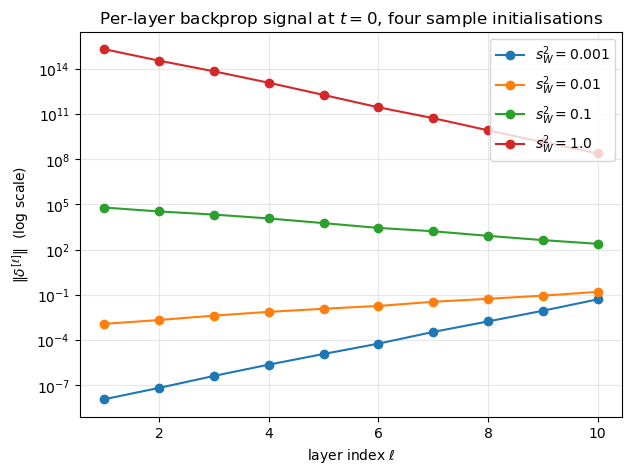

In [3]:
plt.figure(figsize=(7, 5))
for s2 in [1e-3, 1e-2, 1e-1, 1.0]:
    plt.semilogy(range(1, 11), probe(s2), 'o-', label=fr'$s_W^2 = {s2}$')
plt.xlabel(r'layer index $\ell$')
plt.ylabel(r'$\|\delta^{[\ell]}\|$  (log scale)')
plt.title(r'Per-layer backprop signal at $t = 0$, four sample initialisations')
plt.legend(); plt.grid(alpha=0.3, which='both')
plt.show()

**Four initialisations, four different slopes.** Two slope upward (the gradient vanishes toward the early layers), two slope downward (the gradient explodes toward the early layers). None is flat.

By continuity, there must be a value of $s_W^2$ between them at which the slope is exactly zero, i.e.\ the gradient propagates without growth or decay across the $L = 10$ layers. The Week 4 theory tutorial says this same value should also be the one at which SGD trains the network: with stable per-layer gradients, a single learning rate updates every layer's weights by comparable amounts.

Your job is to find that value of $s_W^2$ and verify both predictions in one go.

> ### <font color="#1b5e20">Solution</font>
>
> The magic value is $m = 2$, giving $s_W^2 = 2/n$. The cell below runs the experiment for $m = 1, 2, 3$ side by side at $n = 64$, so you can see all three regimes (vanishing / stable / exploding) in one figure.

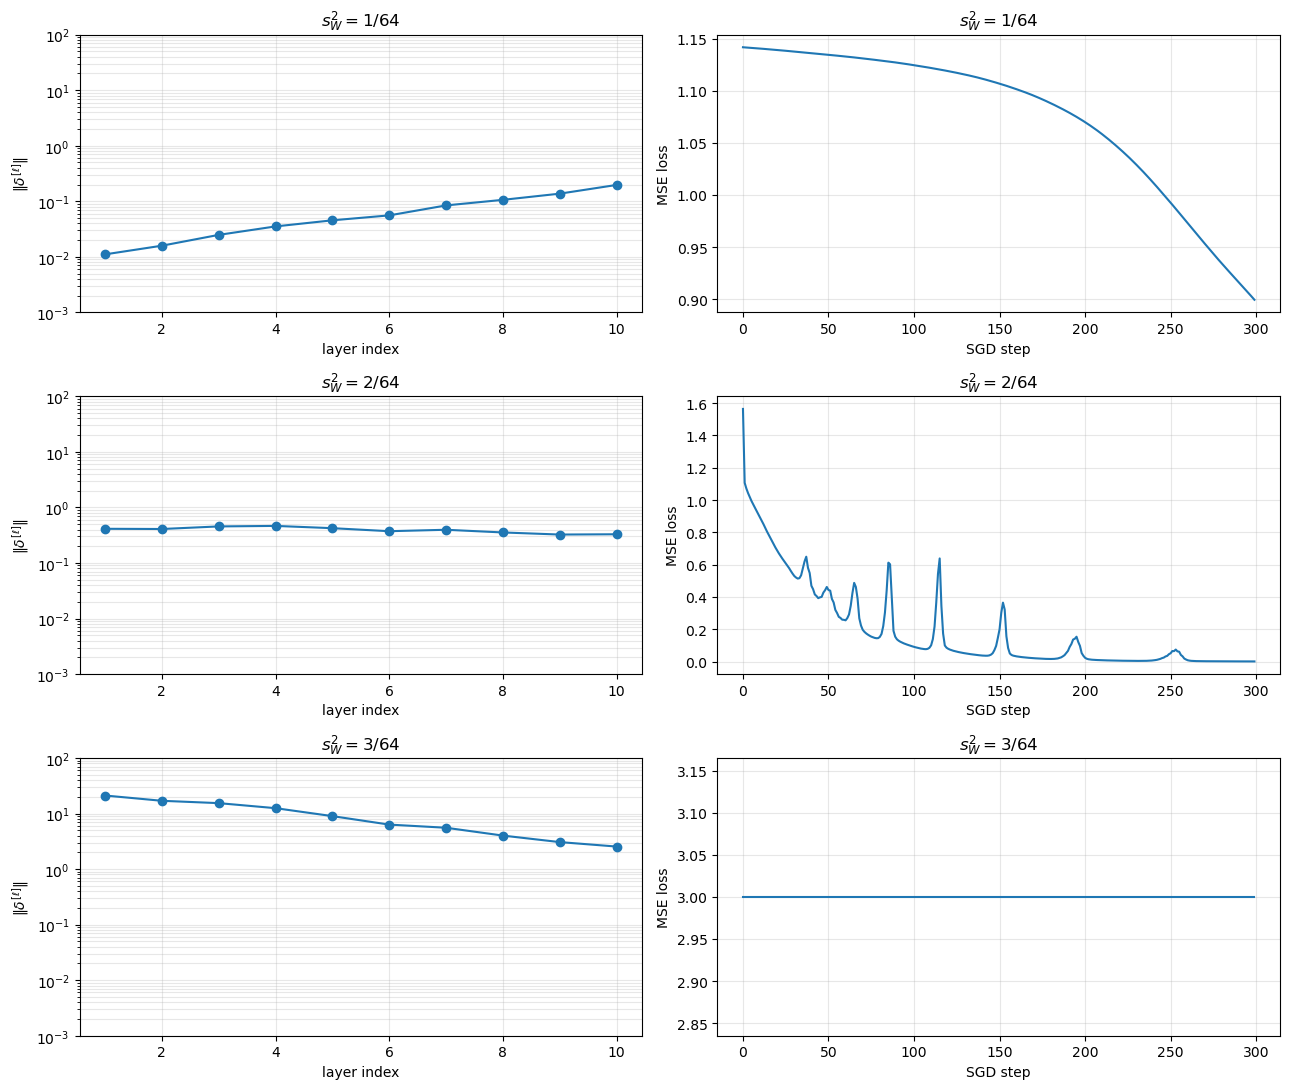

In [4]:
# SOLUTION: m = 2 is the magic value, giving s_W^2 = 2/n.
# Below: side-by-side comparison of m = 1, 2, 3 at n = 64.

n = 64

fig, axes = plt.subplots(3, 2, figsize=(13, 11))
for row, m in enumerate([1, 2, 3]):
    s_squared = m / n

    # left: per-layer norms at t = 0
    torch.manual_seed(0)
    model = DeepReLU_MLP(L=10, n=n, s_squared=s_squared)
    loss = ((model(X) - y) ** 2).mean()
    loss.backward()
    norms = model.delta_norms()
    axes[row, 0].plot(range(1, 11), norms, 'o-')
    axes[row, 0].set_yscale('log')
    axes[row, 0].set(xlabel='layer index',
                     ylabel=r'$\|\delta^{[\ell]}\|$',
                     title=fr'$s_W^2 = {m}/{n}$')
    axes[row, 0].set_ylim(1e-3, 1e2)
    axes[row, 0].grid(alpha=0.3, which='both')

    # right: SGD training
    torch.manual_seed(0)
    model = DeepReLU_MLP(L=10, n=n, s_squared=s_squared)
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    losses = []
    for _ in range(300):
        optimizer.zero_grad()
        loss = ((model(X) - y) ** 2).mean()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    losses = np.array(losses)
    losses[~np.isfinite(losses) | (losses > 3)] = 3
    axes[row, 1].plot(losses)
    axes[row, 1].set(xlabel='SGD step', ylabel='MSE loss',
                     title=fr'$s_W^2 = {m}/{n}$')
    axes[row, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Read the three rows of the figure above:

* **$m = 1$ (top row).** Per-layer gradient norm slopes clearly upward (the gradient vanishes at the early layers, so they receive tiny updates). SGD makes only slow progress: the loss drifts from $1.14$ down toward $0.9$ over 300 steps, far from converged.
* **$m = 2$ (middle row).** Per-layer gradient norm is approximately flat across all 10 layers, and SGD drives the MSE loss to nearly zero. This is the correct answer.
* **$m = 3$ (bottom row).** Per-layer norm has a clearly negative slope (the gradient explodes at the early layers), and SGD diverges, hitting the clipping ceiling at $3$ within the first step.

Repeating the same scan with $n = 32$ or $n = 128$ shows that $m = 2$ remains the answer at every width. Hence the rule is
$$
  s_W^2 \;=\; \frac{2}{n},
$$
which is exactly the **He initialisation criterion** derived analytically in the Week 4 theory tutorial (*Backpropagating the Variance*). The empirical discovery here and the theoretical derivation there agree on the same constant, $2/n$, for the same structural reason: ReLU silences half the gradient at each backward layer, and the weight variance must double to compensate.